BUILDING A CHATBOT WITH HUMAN IN THE LOOP ASSISSTANCE

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002169BF61BE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002169BF62900>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

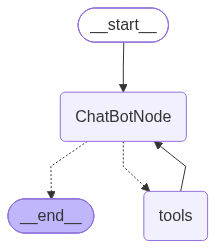

In [6]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt
from langchain.tools import tool
from langchain_tavily import TavilySearch
from IPython.display import display, Image

class State(TypedDict):
    messages : Annotated[list,add_messages]

search_tool = TavilySearch(max_results=2)

@tool
def human(query : str) -> str:
    """Request for assisstance from a human."""
    human_response = interrupt({"query" : query})
    return human_response["data"]

tools = [search_tool,human]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("ChatBotNode",chatbot)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_edge(START,"ChatBotNode")
graph_builder.add_conditional_edges("ChatBotNode",tools_condition)
graph_builder.add_edge("tools","ChatBotNode")
graph = graph_builder.compile(checkpointer=InMemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
config = {"configurable" : {"thread_id" : "thread"}}

for event in graph.stream({"messages" : "I require expert guidance and assisstance for building an AI agent. Could you please request assisstance for me?"},config,stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I require expert guidance and assisstance for building an AI agent. Could you please request assisstance for me?
================================== Ai Message ==================================
Tool Calls:
  human (fc_59897acf-5062-47c9-9326-2923146f8d2a)
 Call ID: fc_59897acf-5062-47c9-9326-2923146f8d2a
  Args:
    query: I require expert guidance and assistance for building an AI agent. Could you please request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human (fc_59897acf-5062-47c9-9326-2923146f8d2a)
 Call ID: fc_59897acf-5062-47c9-9326-2923146f8d2a
  Args:
    query: I require expert guidance and assistance for building an AI agent. Could you please request assistance for me?


In [15]:
human_command = Command(
    resume={
        "data" : "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents."
    }
)

for event in graph.stream(human_command,config,stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human (fc_59897acf-5062-47c9-9326-2923146f8d2a)
 Call ID: fc_59897acf-5062-47c9-9326-2923146f8d2a
  Args:
    query: I require expert guidance and assistance for building an AI agent. Could you please request assistance for me?
================================= Tool Message =================================
Name: human

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely! I’ll give you a practical, step‑by‑step roadmap for building a robust AI agent, plus a quick deep‑dive into LangGraph (the tool the experts just mentioned) and a few alternative stacks you might consider. Feel free to tell me more about your specific use‑case (e.g., web‑scraping bot, customer‑support chatbot, personal produ